In [1]:
import requests
import time
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
from tqdm.notebook import tqdm


class CourseDataPipeline:
    """
    Streams course catalog + simulated enrollment events
    from the Coursera public API for `duration_minutes`.
    Appends paginated data every 10 seconds (tqdm-tracked).
    """

    def __init__(self):
        self.base_url    = 'https://api.coursera.org/api/courses.v1'
        self.partner_url = 'https://api.coursera.org/api/partners.v1'

    def sync_data(self, duration_minutes=5):
        stop_time   = datetime.now() + timedelta(minutes=duration_minutes)
        total_steps = duration_minutes * 6  # pulse every 10 s

        print(f' Data Source : {self.base_url}')
        print(f' Starting {duration_minutes}-minute extraction session...')

        start_offset = 0
        with tqdm(total=total_steps, desc='Syncing Course Bundles') as pbar:
            while datetime.now() < stop_time:
                try:
                    # 1. Fetch Courses (paginated)
                    params = {
                        'start' : start_offset,
                        'limit' : 20,
                        'fields': 'id,name,description,domainTypes,primaryLanguages,partnerIds',
                    }
                    res      = requests.get(self.base_url, params=params, timeout=15)
                    elements = res.json().get('elements', [])

                    if not elements:
                        start_offset = 0
                        time.sleep(10)
                        pbar.update(1)
                        continue

                    cdf = pd.DataFrame([{
                        'courseId'   : c.get('id', ''),
                        'name'       : c.get('name', ''),
                        'description': c.get('description', ''),
                        'domainTypes': str(c.get('domainTypes', [])),
                        'language'   : (c.get('primaryLanguages') or ['en'])[0],
                        'partnerIds' : str(c.get('partnerIds', [])),
                    } for c in elements])

                    cdf.to_csv('courses_raw.csv', mode='a', index=False,
                               header=not os.path.exists('courses_raw.csv'))

                    # 2. Simulate enrollment events (ground-truth)
                    interactions = [
                        {'userId'  : int(np.random.randint(1, 300)),
                         'courseId': c.get('id', '')}
                        for c in elements
                        for _ in range(int(np.random.randint(1, 6)))
                    ]
                    pd.DataFrame(interactions).to_csv(
                        'user_actuals.csv', mode='a', index=False,
                        header=not os.path.exists('user_actuals.csv'))

                    start_offset += 20
                    pbar.update(1)
                    time.sleep(10)

                except Exception as e:
                    print(f'Sync Error: {e}')
                    break

        print(f' Session Complete at {datetime.now().strftime("%H:%M:%S")}')


pipeline = CourseDataPipeline()
pipeline.sync_data(duration_minutes=5)

 Data Source : https://api.coursera.org/api/courses.v1
 Starting 5-minute extraction session...


Syncing Course Bundles:   0%|          | 0/30 [00:00<?, ?it/s]

 Session Complete at 14:22:29


**Data Pre-Processing Pipeline**

In [2]:
import re
import string
import json as _json


class CoursePreprocessor:
    """
    Reads courses_raw.csv, deduplicates, engineers features.
    Weighted bag: category × 3  |  name × 2  |  description × 1
    """

    def __init__(self, filepath='courses_raw.csv'):
        self.filepath = filepath

    @staticmethod
    def _extract_domain(domain_str):
        try:
            parsed = _json.loads(str(domain_str).replace("'", '"'))
            if parsed:
                return parsed[0].get('domainId', 'general').replace('-', ' ')
        except Exception:
            pass
        return 'general'

    @staticmethod
    def _clean(text):
        text = str(text).lower()
        text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
        return text.strip()

    def process(self):
        df = pd.read_csv(self.filepath).drop_duplicates(subset='courseId').copy()

        # 1. Category extraction
        df['category'] = df['domainTypes'].apply(self._extract_domain)

        # 2. Language bucket
        df['lang_label'] = df['language'].apply(
            lambda x: 'english' if str(x).lower() == 'en' else 'multilingual')

        # 3. Weighted metadata  (category ×3, name ×2, description ×1)
        df['final_features'] = (
            df['category'].apply(self._clean) + ' ' +
            df['category'].apply(self._clean) + ' ' +
            df['category'].apply(self._clean) + ' ' +
            df['name'].apply(self._clean)      + ' ' +
            df['name'].apply(self._clean)      + ' ' +
            df['description'].apply(self._clean)
        )

        return df

**Exploratory Data Analysis**

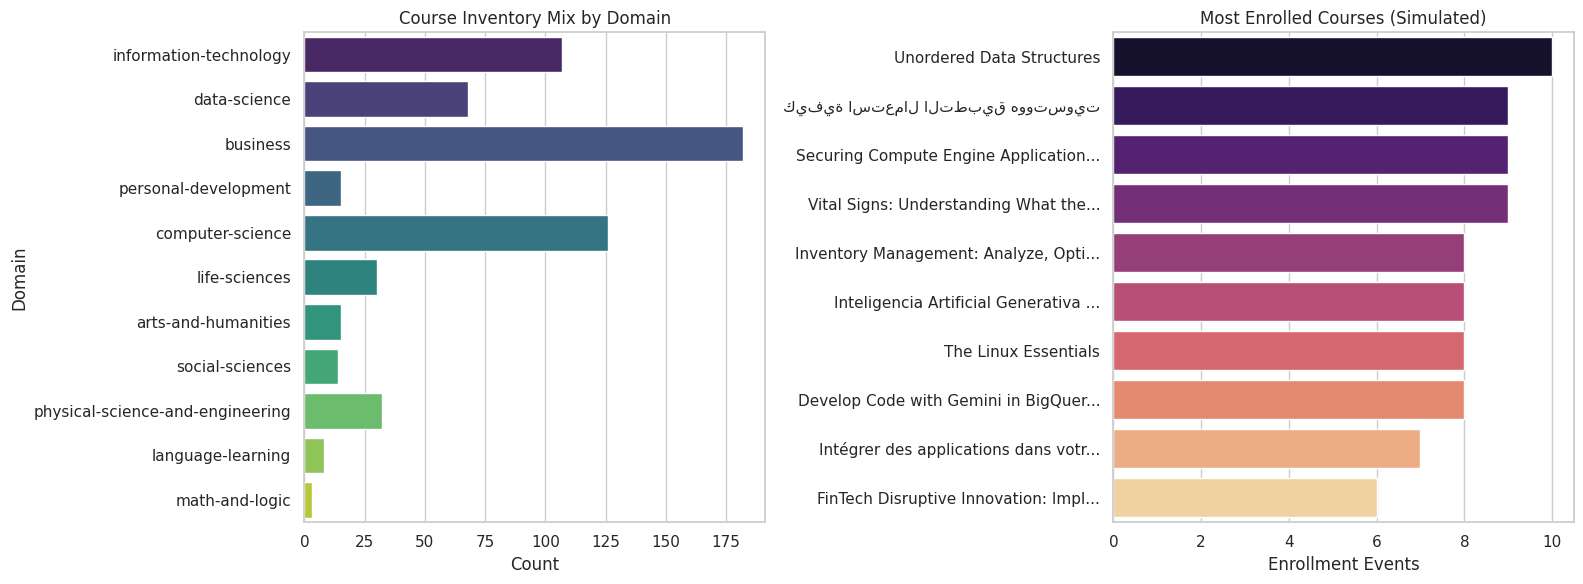

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt


def run_comprehensive_eda():
    cdf = pd.read_csv('courses_raw.csv').drop_duplicates(subset='courseId')
    idf = pd.read_csv('user_actuals.csv')

    import json as _j
    def _cat(d):
        try:
            p = _j.loads(str(d).replace("'", '"'))
            return p[0].get('domainId', 'general') if p else 'general'
        except Exception:
            return 'general'

    cdf['category'] = cdf['domainTypes'].apply(_cat)

    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1 — Category Distribution
    sns.countplot(data=cdf, y='category', hue='category',
                  palette='viridis', ax=axes[0], legend=False)
    axes[0].set_title('Course Inventory Mix by Domain')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Domain')

    # Plot 2 — Top Enrolled Courses
    top = idf['courseId'].value_counts().head(10).reset_index()
    top.columns = ['courseId', 'enrollments']
    top = top.merge(cdf[['courseId', 'name']], on='courseId', how='left')
    top['name'] = top['name'].apply(
        lambda x: str(x)[:35] + '...' if len(str(x)) > 35 else str(x))
    sns.barplot(data=top, x='enrollments', y='name', hue='name',
                palette='magma', ax=axes[1], legend=False)
    axes[1].set_title('Most Enrolled Courses (Simulated)')
    axes[1].set_xlabel('Enrollment Events')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()


run_comprehensive_eda()

/tmp/ipykernel_1351/1320006055.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_dashboard_part1.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


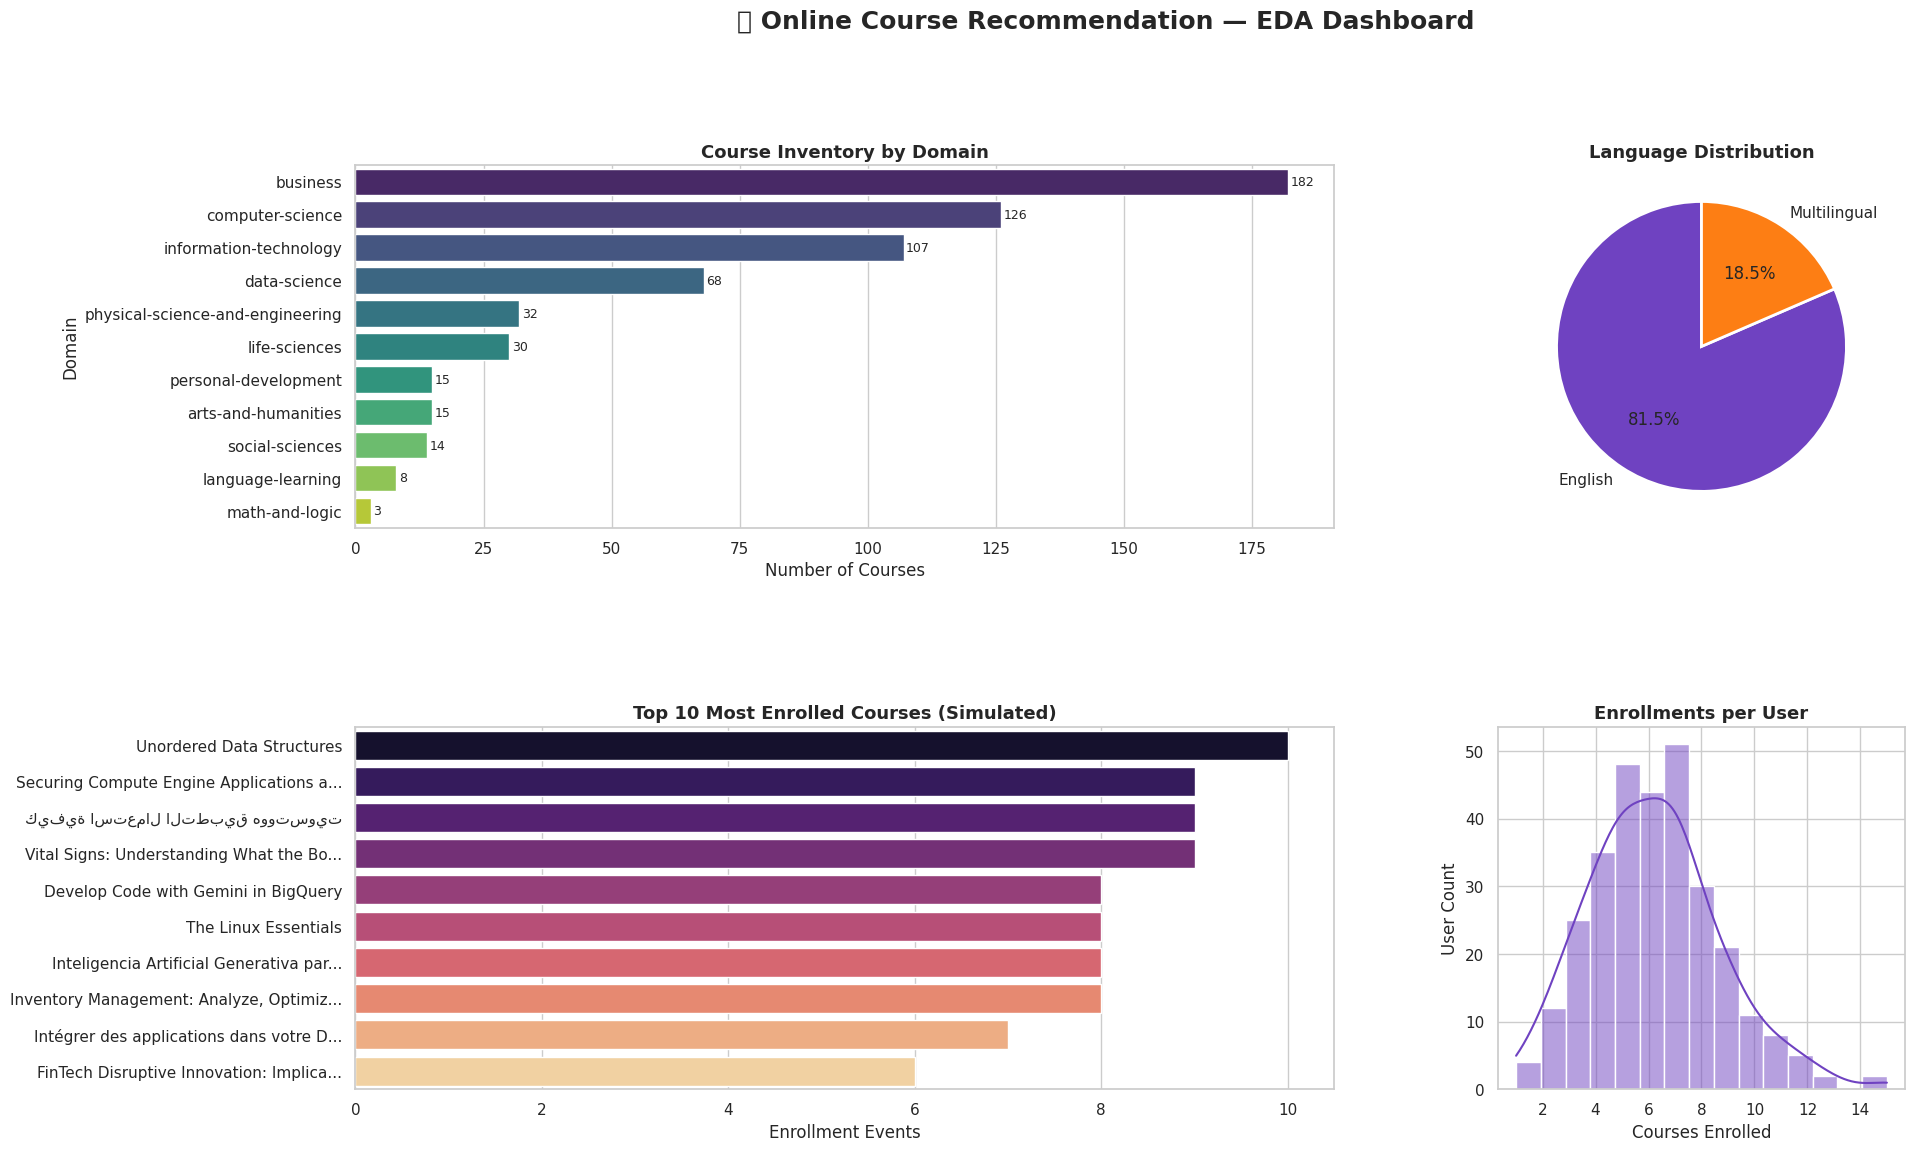

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_1351/1320006055.py:128: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_dashboard_part2.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


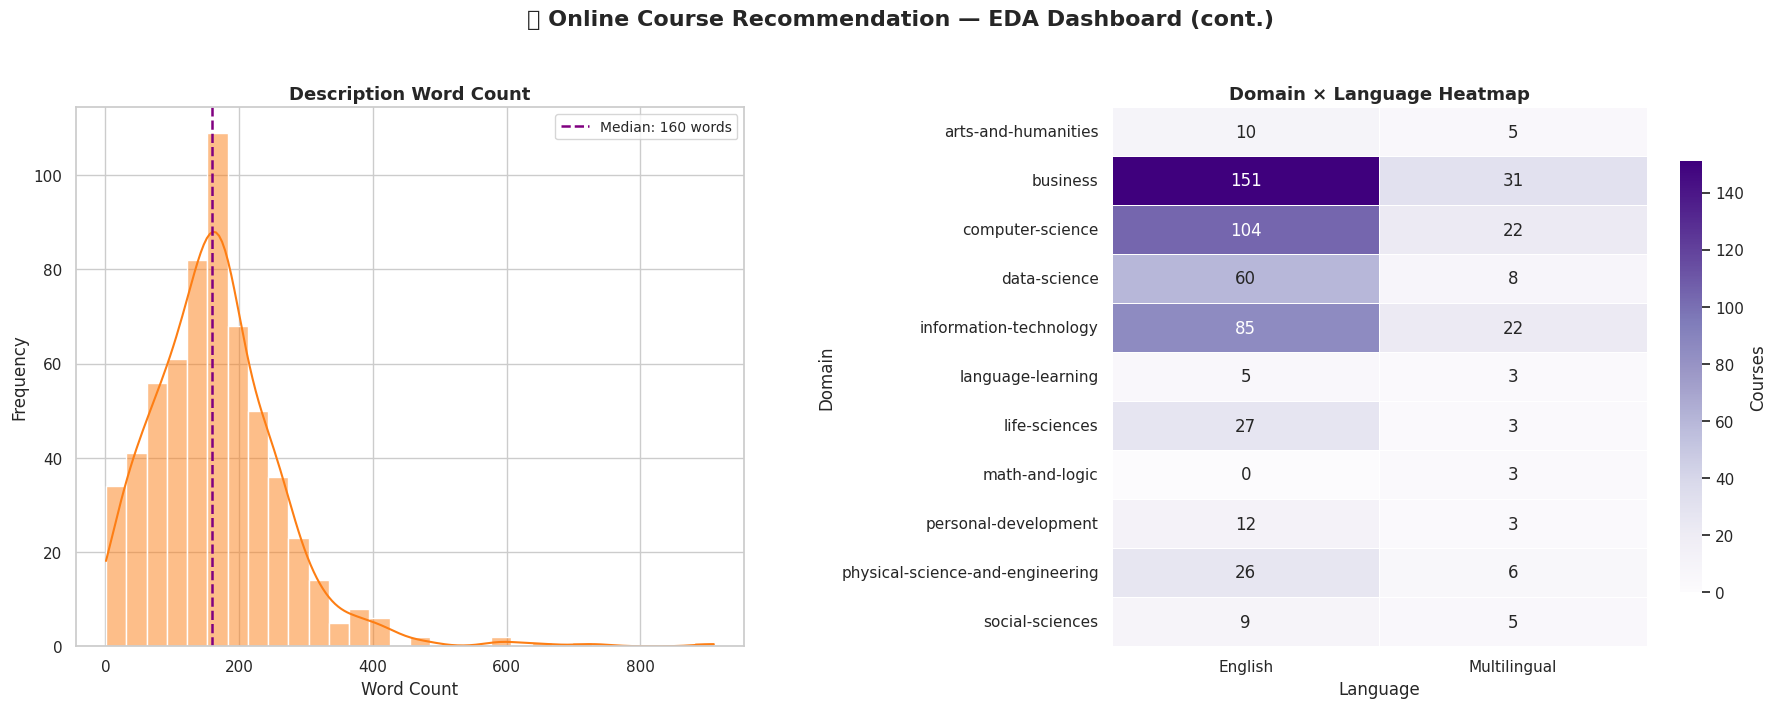

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json as _j
import numpy as np
from collections import Counter
import re


def run_comprehensive_eda():
    #  Load Data
    cdf = pd.read_csv('courses_raw.csv').drop_duplicates(subset='courseId').copy()
    idf = pd.read_csv('user_actuals.csv')

    #  Feature Engineering
    def _cat(d):
        try:
            p = _j.loads(str(d).replace("'", '"'))
            return p[0].get('domainId', 'general') if p else 'general'
        except Exception:
            return 'general'

    cdf['category']    = cdf['domainTypes'].apply(_cat)
    cdf['lang_label']  = cdf['language'].apply(
        lambda x: 'English' if str(x).lower() == 'en' else 'Multilingual')
    cdf['desc_length'] = cdf['description'].apply(lambda x: len(str(x).split()))
    cdf['name_length'] = cdf['name'].apply(lambda x: len(str(x).split()))

    enroll_counts          = idf['courseId'].value_counts().reset_index()
    enroll_counts.columns  = ['courseId', 'enrollments']
    cdf = cdf.merge(enroll_counts, on='courseId', how='left')
    cdf['enrollments'] = cdf['enrollments'].fillna(0).astype(int)

    user_enroll           = idf.groupby('userId')['courseId'].count().reset_index()
    user_enroll.columns   = ['userId', 'courses_enrolled']

    sns.set_theme(style='whitegrid', palette='muted')

    # FIGURE 1 — Top 4 plots (2×2 grid)
    fig1 = plt.figure(figsize=(20, 12))
    fig1.suptitle('📊 Online Course Recommendation — EDA Dashboard',
                  fontsize=18, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.55, wspace=0.4)

    #  Plot 1 : Domain Distribution
    ax1 = fig1.add_subplot(gs[0, :2])
    domain_counts = cdf['category'].value_counts().reset_index()
    domain_counts.columns = ['category', 'count']
    bars = sns.barplot(data=domain_counts, x='count', y='category',
                       hue='category', palette='viridis', ax=ax1, legend=False)
    for bar in bars.patches:
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{int(bar.get_width())}', va='center', fontsize=9)
    ax1.set_title('Course Inventory by Domain', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Number of Courses')
    ax1.set_ylabel('Domain')

    #  Plot 2 : Language Distribution (Pie)
    ax2 = fig1.add_subplot(gs[0, 2])
    lang_counts = cdf['lang_label'].value_counts()
    ax2.pie(lang_counts.values,
            labels=lang_counts.index,
            autopct='%1.1f%%',
            colors=['#6f42c1', '#fd7e14'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
    ax2.set_title('Language Distribution', fontsize=13, fontweight='bold')

    # Plot 3 : Top 10 Most Enrolled Courses
    ax3 = fig1.add_subplot(gs[1, :2])
    top_courses = (cdf[cdf['enrollments'] > 0]
                   .nlargest(10, 'enrollments')[['name', 'enrollments', 'category']])
    top_courses['short_name'] = top_courses['name'].apply(
        lambda x: x[:38] + '...' if len(x) > 38 else x)
    sns.barplot(data=top_courses, x='enrollments', y='short_name',
                hue='short_name', palette='magma', ax=ax3, legend=False)
    ax3.set_title('Top 10 Most Enrolled Courses (Simulated)',
                  fontsize=13, fontweight='bold')
    ax3.set_xlabel('Enrollment Events')
    ax3.set_ylabel('')

    #  Plot 4 : Enrollments per User
    ax4 = fig1.add_subplot(gs[1, 2])
    sns.histplot(data=user_enroll, x='courses_enrolled',
                 bins=15, kde=True, color='#6f42c1', ax=ax4)
    ax4.set_title('Enrollments per User', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Courses Enrolled')
    ax4.set_ylabel('User Count')

    plt.savefig('eda_dashboard_part1.png', dpi=150, bbox_inches='tight')
    plt.show()

    # FIGURE 2 — Plot 5 & 6 separated with wide spacing

    fig2, (ax5, ax6) = plt.subplots(
        1, 2,
        figsize=(22, 7),
        gridspec_kw={'wspace': 0.55}   # <-- key fix: wide gap
    )

    fig2.suptitle('📊 Online Course Recommendation — EDA Dashboard (cont.)',
                  fontsize=16, fontweight='bold', y=1.02)

    #  Plot 5 : Description Word Count
    sns.histplot(data=cdf, x='desc_length',
                 bins=30, kde=True, color='#fd7e14', ax=ax5)
    ax5.axvline(cdf['desc_length'].median(), color='purple',
                linestyle='--', linewidth=1.8,
                label=f"Median: {int(cdf['desc_length'].median())} words")
    ax5.set_title('Description Word Count', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Word Count', fontsize=12)
    ax5.set_ylabel('Frequency', fontsize=12)
    ax5.legend(fontsize=10)

    #  Plot 6 : Domain × Language Heatmap
    pivot = (cdf.groupby(['category', 'lang_label'])
               .size().unstack(fill_value=0))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='Purples',
                linewidths=0.5, ax=ax6,
                cbar_kws={'label': 'Courses', 'shrink': 0.8})
    ax6.set_title('Domain × Language Heatmap', fontsize=13, fontweight='bold')
    ax6.set_xlabel('Language', fontsize=12)
    ax6.set_ylabel('Domain', fontsize=12)
    ax6.tick_params(axis='x', rotation=0)
    ax6.tick_params(axis='y', rotation=0)

    plt.savefig('eda_dashboard_part2.png', dpi=150, bbox_inches='tight')
    plt.show()


run_comprehensive_eda()

**Recommendation Engine + Interactive UI(TF-IDF)**

In [5]:
#  Colab widget fix (MUST run first)
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("Colab widget manager enabled.")
except ImportError:
    print("Running in Jupyter — no fix needed.")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output


class CourseRecommender:
    def __init__(self, processed_df):
        self.df         = processed_df.reset_index(drop=True)
        self.vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
        self.tfidf      = self.vectorizer.fit_transform(self.df['final_features'])
        self.sim        = cosine_similarity(self.tfidf, self.tfidf)

    def recommend(self, course_id, k=4):
        matches = self.df[self.df['courseId'] == course_id]
        if matches.empty:
            return self.df.head(k)
        idx    = matches.index[0]
        scores = sorted(enumerate(self.sim[idx]),
                        key=lambda x: x[1], reverse=True)[1:k+1]
        return self.df.iloc[[i[0] for i in scores]]


#  Instantiate
preprocessor = CoursePreprocessor()
processed_df = preprocessor.process()
engine       = CourseRecommender(processed_df)

print(f"Engine ready — {len(engine.df)} courses loaded.")


#  Color Palette (CSS color names only)
PRIMARY     = "purple"       # button, badges, headings
SECONDARY   = "orange"       # currently viewing border
CARD_BG     = "lavender"     # card background
TITLE_COLOR = "indigo"       # section sub-heading
BADGE_COLOR = "orange"       # language badge
NAME_COLOR  = "darkviolet"   # course name text


# UI
course_options = [(str(r['name'])[:60], r['courseId'])
                  for _, r in engine.df.iterrows()]

dropdown = widgets.Dropdown(
    options=course_options,
    description='Course:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='520px')
)
btn = widgets.Button(
    description='Get Recommendations',
    button_style='',
    layout=widgets.Layout(width='220px')
)
btn.style.button_color = PRIMARY
btn.style.text_color   = 'white'

out = widgets.Output()


def on_click(b):
    out.clear_output()
    with out:
        try:
            selected_id = dropdown.value
            match = engine.df[engine.df['courseId'] == selected_id]

            if match.empty:
                print("Course not found in engine. Try another.")
                return

            current = match.iloc[0]
            recs    = engine.recommend(selected_id, k=4)

            if recs.empty:
                print("No recommendations found.")
                return

            #  Currently Viewing card
            display(HTML(f"""
            <div style='border-left:6px solid {SECONDARY};
                        background:{CARD_BG};
                        padding:15px;margin-bottom:20px;border-radius:8px;
                        box-shadow:0 3px 8px rgba(0,0,0,0.15)'>
              <h4 style='margin:0 0 10px 0;color:{PRIMARY}'>
                📖 Currently Viewing</h4>
              <div style='display:flex;justify-content:space-between;
                          align-items:center'>
                <div>
                  <b style='font-size:16px;color:{NAME_COLOR}'>
                    {current['name']}</b><br>
                  <span style='color:grey;font-size:12px;
                               text-transform:uppercase'>
                    {current['category']}</span>
                </div>
                <div style='text-align:right'>
                  <span style='font-size:11px;
                               background:{BADGE_COLOR};
                               color:white;
                               padding:3px 10px;
                               border-radius:12px;
                               font-weight:bold'>
                    {current.get('lang_label', 'en')}</span>
                </div>
              </div>
            </div>
            <h4 style='margin-left:5px;color:{TITLE_COLOR}'>
              ✨ Similar Courses You Might Like</h4>
            """))

            # Recommendation cards
            cols = ''.join([
                f"""
                <div style='border:1px solid plum;
                            float:left;width:22%;
                            margin:1%;padding:12px;border-radius:10px;
                            background:{CARD_BG};min-height:170px;
                            box-shadow:0 2px 6px rgba(0,0,0,0.12)'>
                  <p style='font-size:14px;font-weight:bold;height:60px;
                            overflow:hidden;margin-bottom:8px;
                            color:{NAME_COLOR}'>
                    {r['name']}</p>
                  <p style='font-size:10px;color:grey;
                            text-transform:uppercase;margin-bottom:6px'>
                    {r['category']}</p>
                  <div style='font-size:9px;
                              background:{PRIMARY};
                              color:white;
                              display:inline-block;
                              padding:3px 8px;
                              border-radius:6px;
                              font-weight:bold'>
                    {r.get('lang_label','en')}</div>
                </div>"""
                for _, r in recs.iterrows()
            ])
            display(HTML(cols + "<div style='clear:both'></div>"))

        except Exception as e:
            print(f"Error: {e}")


btn.on_click(on_click)

display(HTML(f"""
<h2 style='font-family:sans-serif;
           color:{PRIMARY};
           border-bottom:3px solid {SECONDARY};
           padding-bottom:8px;
           display:inline-block'>
   Smart Course Recommender Portal
</h2>"""))
display(widgets.HBox([dropdown, btn]))
display(out)

Colab widget manager enabled.
Engine ready — 600 courses loaded.


Output()

**Evaluation Metrics**

In [6]:
def show_performance_dashboard(engine, k=5):
    actuals  = pd.read_csv('user_actuals.csv')
    user_ids = actuals['userId'].unique()
    hits     = 0
    rr_list  = []

    for uid in user_ids:
        true_items = set(actuals[actuals['userId'] == uid]['courseId'].tolist())
        if len(true_items) < 2:
            continue

        seed    = list(true_items)[0]
        targets = list(true_items)[1:]

        if seed not in engine.df['courseId'].values:
            continue

        preds = engine.recommend(seed, k)['courseId'].tolist()

        if any(p in targets for p in preds):
            hits += 1

        for i, p in enumerate(preds):
            if p in targets:
                rr_list.append(1 / (i + 1))
                break
        else:
            rr_list.append(0)

    eligible = len([uid for uid in user_ids
                    if len(set(actuals[actuals['userId'] == uid]['courseId'])) >= 2])

    print(f'--- Dashboard Metrics  K={k} ---')
    print(f'Hit Rate              {hits / max(eligible, 1):.4f}')
    print(f'Mean Reciprocal Rank  {np.mean(rr_list) if rr_list else 0:.4f}')


show_performance_dashboard(engine)

--- Dashboard Metrics  K=5 ---
Hit Rate              0.0510
Mean Reciprocal Rank  0.0287
